In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import utulek

utulek.platform.import_globals_notebook(globals())

base_module = utulek
IS_NOTEBOOK_KERNEL_CODE = True
NOTEBOOK_NAME = 2026_07_27-t2i.3.ipynb
ASSET_PATH = /home/gilgamesh/main.syncthing/utulek/experiment/2026_07_27-t2i.ipynb.asset/
Loaded `/home/gilgamesh/main.syncthing/utulek/experiment/.env`.
torch: ['NVIDIA GeForce GTX 1080 Ti']
tf: /device:GPU:0
jax: [CudaDevice(id=0)]


In [4]:
from diffusers import ModularPipeline

In [5]:
repo_id = "circlestone-labs/Anima-Base-v1.0-Diffusers"
device = "cuda"

model = AnimaModularPipeline.from_pretrained(repo_id)
model.load_components(torch_dtype=torch.bfloat16)
model.to("cpu")
torch.cuda.empty_cache()

/home/gilgamesh/main.syncthing/utulek/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Guiders are currently an experimental feature under active development. The API is subject to breaking changes in future releases.


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [6]:
blocks = model.blocks
blocks

AnimaAutoBlocks(
  Class: SequentialPipelineBlocks

  Description: Auto Modular pipeline for text-to-image generation using Anima.
      
      Supported workflows:
        - `text2image`: requires `prompt`


  Components:
      text_encoder (`Qwen3Model`)
      tokenizer (`Qwen2Tokenizer`)
      t5_tokenizer (`T5Tokenizer`)
      guider (`ClassifierFreeGuidance`)
      text_conditioner (`AnimaTextConditioner`)
      transformer (`CosmosTransformer3DModel`)
      scheduler (`FlowMatchEulerDiscreteScheduler`)
      vae (`AutoencoderKLQwenImage`)
      image_processor (`VaeImageProcessor`)

  Sub-Blocks:
    [0] text_encoder (AnimaTextEncoderStep)
       Description: Text encoder step that encodes Anima prompts into Qwen states and T5 token ids.

    [1] denoise (AnimaCoreDenoiseStep)
       Description: Denoise block that takes encoded Anima text inputs and runs the denoising process.

    [2] decode (AnimaDecodeStep)
       Description: Decode Anima latents into generated images.

)

In [7]:
b0 = blocks.sub_blocks["text_encoder"]
b0

AnimaTextEncoderStep {
  "_class_name": "AnimaTextEncoderStep",
  "_diffusers_version": "0.39.0"
}

In [8]:
b0p = b0.init_pipeline(repo_id)
b0p.load_components(torch_dtype=torch.bfloat16)

Guiders are currently an experimental feature under active development. The API is subject to breaking changes in future releases.


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [9]:
b0p.to(device)
b0po = b0p(
	prompt="""
masterpiece, best_quality, score_9, safe, @ichimi, 1girl, emilia (re:zero), re:zero kara hajimeru isekai seikatsu.

Emilia confident, smiling, happy, looking at viewer, leading viewer, in a field of flowers.
""",
	negative_prompt=
	"""worst quality, low quality, score_1, score_2, score_3, artist name, blurry, jpeg artifacts, chromatic aberration""",
)
b0po

PipelineState(
  values={
    prompt: '\nmasterpiece, best_quality, score_9, safe, @ichimi, 1girl, emilia (re:zero), re:zero kara hajimeru isekai seikatsu.\n\nEmilia confident, smiling, happy, looking at viewer, leading viewer, in a field of flowers.\n'
    negative_prompt: 'worst quality, low quality, score_1, score_2, score_3, artist name, blurry, jpeg artifacts, chromatic aberration'
    max_sequence_length: 512
    qwen_prompt_embeds: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 65, 1024]))
    qwen_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 65]))
    t5_input_ids: Tensor(dtype=torch.int64, shape=torch.Size([1, 74]))
    t5_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 74]))
    negative_qwen_prompt_embeds: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 31, 1024]))
    negative_qwen_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 31]))
    negative_t5_input_ids: Tensor(dtype=torch.int64, shape=torch.Size([1, 36]))
    nega

In [10]:
b0p.to("cpu")
torch.cuda.empty_cache()

In [11]:
b1 = blocks.sub_blocks["denoise"]
b1

AnimaCoreDenoiseStep(
  Class: SequentialPipelineBlocks

  Description: Denoise block that takes encoded Anima text inputs and runs the denoising process.


  Components:
      text_conditioner (`AnimaTextConditioner`)
      transformer (`CosmosTransformer3DModel`)
      scheduler (`FlowMatchEulerDiscreteScheduler`)
      guider (`ClassifierFreeGuidance`)

  Sub-Blocks:
    [0] text_conditioning (AnimaTextConditioningStep)
       Description: Map Qwen text encoder states and T5 token ids to Cosmos text conditioning for Anima.

    [1] input (AnimaTextInputStep)
       Description: Input processing step that expands Anima prompt embeddings for the requested image batch.

    [2] prepare_latents (AnimaPrepareLatentsStep)
       Description: Prepare noisy image latents and padding mask for Anima denoising.

    [3] set_timesteps (AnimaSetTimestepsStep)
       Description: Set the scheduler timesteps for Anima inference.

    [4] denoise (AnimaDenoiseStep)
       Description: Denoise step 

In [12]:
b1p = b1.init_pipeline(repo_id)
b1p.load_components(torch_dtype=torch.bfloat16)
b1p

/home/gilgamesh/main.syncthing/utulek/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Guiders are currently an experimental feature under active development. The API is subject to breaking changes in future releases.


AnimaModularPipeline {
  "_blocks_class_name": "AnimaCoreDenoiseStep",
  "_class_name": "AnimaModularPipeline",
  "_diffusers_version": "0.39.0",
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler",
    {
      "pretrained_model_name_or_path": "circlestone-labs/Anima-Base-v1.0-Diffusers",
      "revision": null,
      "subfolder": "scheduler",
      "type_hint": [
        "diffusers",
        "FlowMatchEulerDiscreteScheduler"
      ],
      "variant": null
    }
  ],
  "text_conditioner": [
    "diffusers",
    "AnimaTextConditioner",
    {
      "pretrained_model_name_or_path": "circlestone-labs/Anima-Base-v1.0-Diffusers",
      "revision": null,
      "subfolder": "text_conditioner",
      "type_hint": [
        "diffusers",
        "AnimaTextConditioner"
      ],
      "variant": null
    }
  ],
  "transformer": [
    "diffusers",
    "CosmosTransformer3DModel",
    {
      "pretrained_model_name_or_path": "circlestone-labs/Anima-Base-v1.0-Diffusers",
      "revi

In [13]:
type(b1p).default_height = property(lambda self: 512)
type(b1p).default_width = property(lambda self: 512)
type(b1p).vae_scale_factor = property(lambda self: 8)
b1p.to(device)
b1po = b1p(**b0po.values, num_inference_steps=50)
b1po

/home/gilgamesh/main.syncthing/utulek/.venv/lib/python3.11/site-packages/diffusers/modular_pipelines/modular_pipeline.py:2829: UserWarning: Unexpected input 'dict_keys(['prompt', 'negative_prompt', 'max_sequence_length'])' provided. This input will be ignored.
  warnings.warn(f"Unexpected input '{passed_kwargs.keys()}' provided. This input will be ignored.")


  0%|          | 0/50 [00:00<?, ?it/s]

PipelineState(
  values={
    qwen_prompt_embeds: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 65, 1024]))
    qwen_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 65]))
    t5_input_ids: Tensor(dtype=torch.int64, shape=torch.Size([1, 74]))
    t5_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 74]))
    negative_qwen_prompt_embeds: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 31, 1024]))
    negative_qwen_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 31]))
    negative_t5_input_ids: Tensor(dtype=torch.int64, shape=torch.Size([1, 36]))
    negative_t5_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 36]))
    num_images_per_prompt: 1
    height: 512
    width: 512
    latents: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 16, 1, 64, 64]))
    generator: None
    num_inference_steps: 50
    sigmas: None
    prompt_embeds: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 512, 1024]))
    negative_prompt_embeds: T

In [14]:
b1p.to("cpu")
torch.cuda.empty_cache()

In [15]:
b2 = blocks.sub_blocks["decode"]
b2

AnimaDecodeStep(
  Class: SequentialPipelineBlocks

  Description: Decode Anima latents into generated images.


  Components:
      vae (`AutoencoderKLQwenImage`)
      image_processor (`VaeImageProcessor`)

  Sub-Blocks:
    [0] decode (AnimaVaeDecoderStep)
       Description: Step that decodes Anima latents into image tensors.

    [1] postprocess (AnimaProcessImagesOutputStep)
       Description: Postprocess decoded Anima image tensors.

)

In [16]:
b2p = b2.init_pipeline(repo_id)
b2p.load_components(torch_dtype=torch.bfloat16)
b2p

AnimaModularPipeline {
  "_blocks_class_name": "AnimaDecodeStep",
  "_class_name": "AnimaModularPipeline",
  "_diffusers_version": "0.39.0",
  "vae": [
    "diffusers",
    "AutoencoderKLQwenImage",
    {
      "pretrained_model_name_or_path": "circlestone-labs/Anima-Base-v1.0-Diffusers",
      "revision": null,
      "subfolder": "vae",
      "type_hint": [
        "diffusers",
        "AutoencoderKLQwenImage"
      ],
      "variant": null
    }
  ]
}

In [17]:
# b2p.to("cpu")
# b2po = b2p(latents=b1po.values["latents"].to("cpu"))
b2p.to(device)
b2po = b2p(**b1po.values)
b2po

/home/gilgamesh/main.syncthing/utulek/.venv/lib/python3.11/site-packages/diffusers/modular_pipelines/modular_pipeline.py:2829: UserWarning: Unexpected input 'dict_keys(['qwen_prompt_embeds', 'qwen_attention_mask', 't5_input_ids', 't5_attention_mask', 'negative_qwen_prompt_embeds', 'negative_qwen_attention_mask', 'negative_t5_input_ids', 'negative_t5_attention_mask', 'num_images_per_prompt', 'height', 'width', 'generator', 'num_inference_steps', 'sigmas', 'prompt_embeds', 'negative_prompt_embeds', 'batch_size', 'dtype', 'padding_mask', 'timesteps'])' provided. This input will be ignored.
  warnings.warn(f"Unexpected input '{passed_kwargs.keys()}' provided. This input will be ignored.")


PipelineState(
  values={
    latents: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 16, 1, 64, 64]))
    output_type: 'pil'
    images: [<PIL.Image.Image image mode=RGB size=512x512 at 0x7F77F4E389D0>]
  },
  kwargs_mapping={

  }
)

In [18]:
b2p.to("cpu")
torch.cuda.empty_cache()

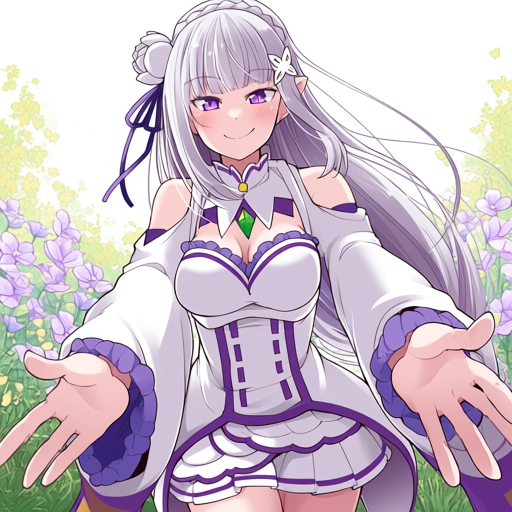

In [19]:
image = b2po.values["images"][0]
image.save("../snowfall/t2i.png")
image